In [1]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

print("✓ Imports complete")
print(f"  SHAP version : {shap.__version__}")

C:\Users\Mansoor\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


✓ Imports complete
  SHAP version : 0.42.0


In [2]:
with open("../models/champion_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("../data/processed/featured/feature_metadata.json") as f:
    feature_meta = json.load(f)

FEATURES = feature_meta["final_features"]
TARGET   = feature_meta["target"]

df_train = pd.read_parquet(
    "../data/processed/featured/train_featured.parquet", engine="fastparquet"
)
df_test = pd.read_parquet(
    "../data/processed/featured/test_featured.parquet", engine="fastparquet"
)

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET]

print("✓ Model and data loaded")
print(f"  Champion  : XGBoost (tuned)")
print(f"  X_train   : {X_train.shape}")
print(f"  X_test    : {X_test.shape}")
print(f"  Features  : {len(FEATURES)}")

✓ Model and data loaded
  Champion  : XGBoost (tuned)
  X_train   : (67493, 44)
  X_test    : (14471, 44)
  Features  : 44


In [3]:
# Use a sample for speed — 3000 rows is sufficient for stable SHAP estimates
SHAP_SAMPLE_SIZE = 3000
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=SHAP_SAMPLE_SIZE, replace=False)
X_shap = X_test.iloc[sample_idx].reset_index(drop=True)
y_shap = y_test.iloc[sample_idx].reset_index(drop=True)

print(f"Computing SHAP values on {SHAP_SAMPLE_SIZE} test samples...")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print(f"✓ SHAP values computed")
print(f"  shap_values shape : {shap_values.shape}")
print(f"  Expected value    : {explainer.expected_value:.4f} days")
print(f"  (= model base rate — mean prediction before any features)")

Computing SHAP values on 3000 test samples...
✓ SHAP values computed
  shap_values shape : (3000, 44)
  Expected value    : -11.2357 days
  (= model base rate — mean prediction before any features)


In [4]:
shap_importance = pd.DataFrame({
    "feature"    : FEATURES,
    "mean_abs_shap" : np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("GLOBAL FEATURE IMPORTANCE — Mean |SHAP| (test sample)\n")
print(f"  {'Rank':<6} {'Feature':<40} {'Mean |SHAP|':>12}")
print("  " + "-" * 62)
for i, row in shap_importance.iterrows():
    bar = "█" * int(row["mean_abs_shap"] * 10)
    print(f"  {i+1:<6} {row['feature']:<40} {row['mean_abs_shap']:>12.4f}  {bar}")

GLOBAL FEATURE IMPORTANCE — Mean |SHAP| (test sample)

  Rank   Feature                                   Mean |SHAP|
  --------------------------------------------------------------
  1      estimated_delivery_days                        4.2850  ██████████████████████████████████████████
  2      purchase_month                                 1.3254  █████████████
  3      customer_state_avg_variance                    1.0204  ██████████
  4      same_state                                     0.8084  ████████
  5      seller_avg_variance                            0.6794  ██████
  6      seller_late_rate                               0.5230  █████
  7      total_freight                                  0.4509  ████
  8      seller_std_variance                            0.4284  ████
  9      purchase_year                                  0.3280  ███
  10     same_region                                    0.3019  ███
  11     purchase_quarter                               0.2507  ██
  

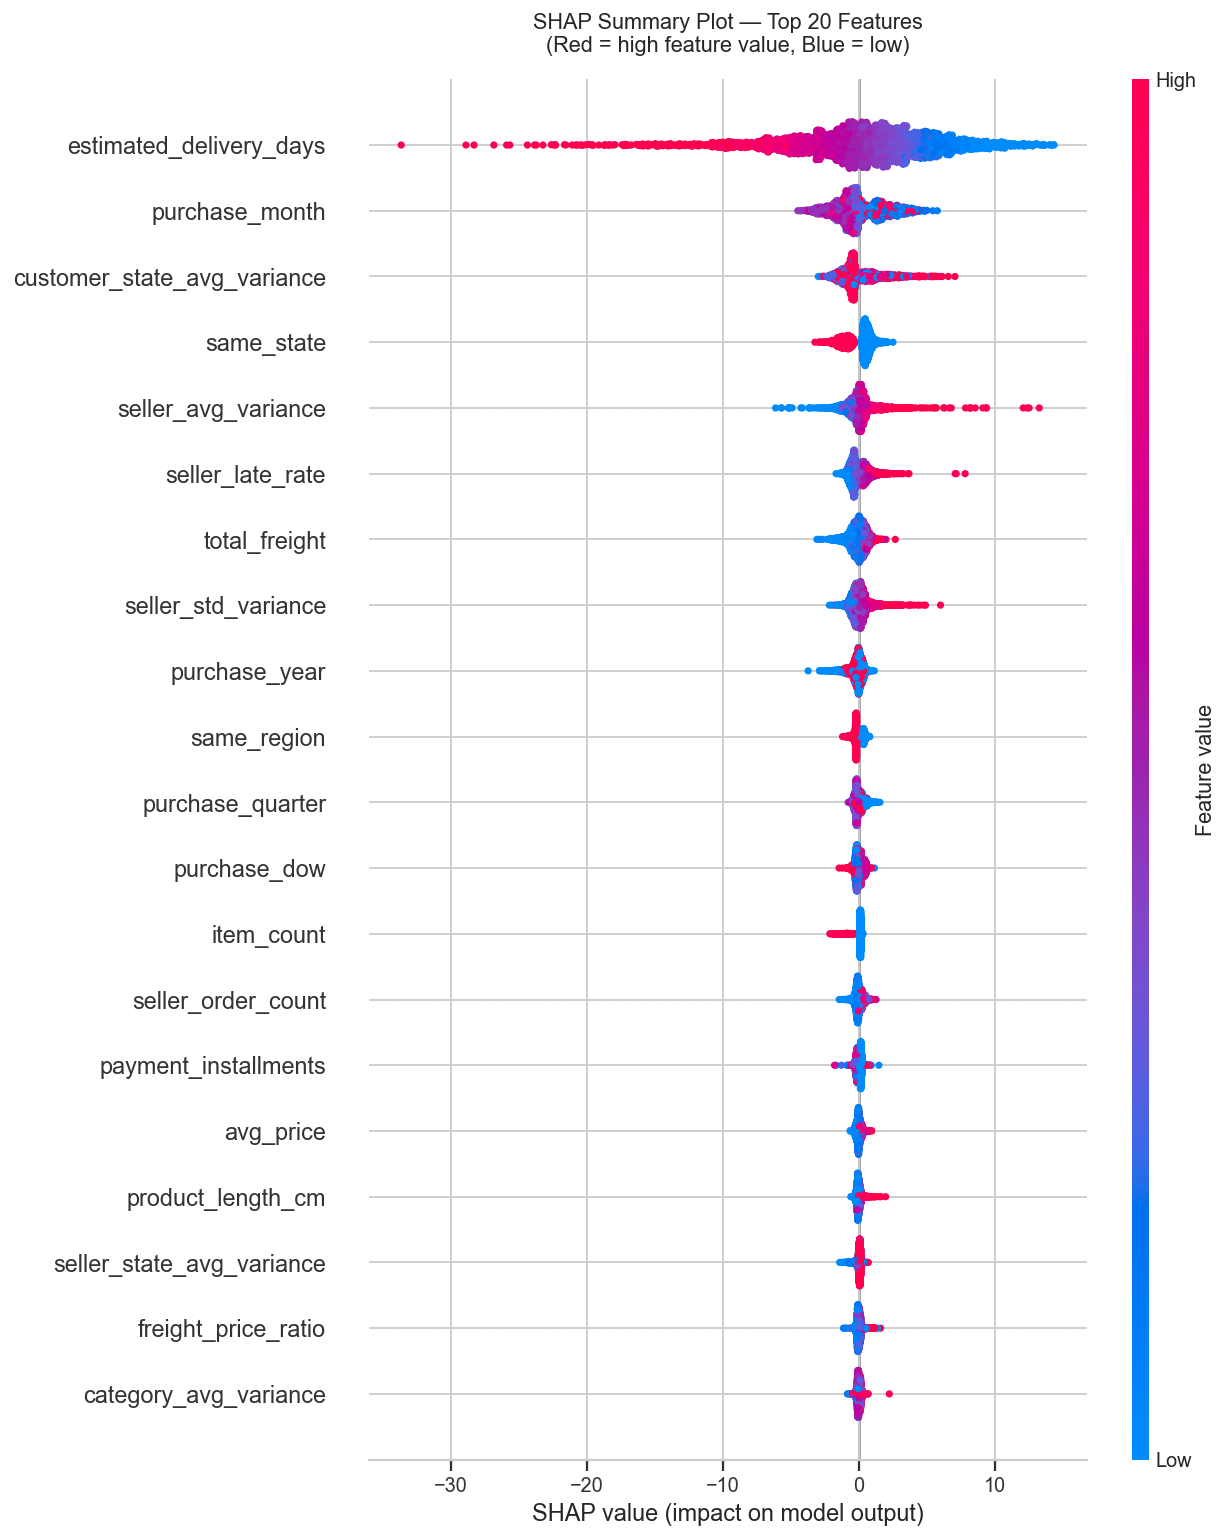

✓ SHAP summary plot saved


In [5]:
plt.figure(figsize=(10, 12))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURES,
    max_display=20,
    show=False,
    plot_size=(10, 12)
)
plt.title("SHAP Summary Plot — Top 20 Features\n(Red = high feature value, Blue = low)", 
          fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/shap_summary.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ SHAP summary plot saved")

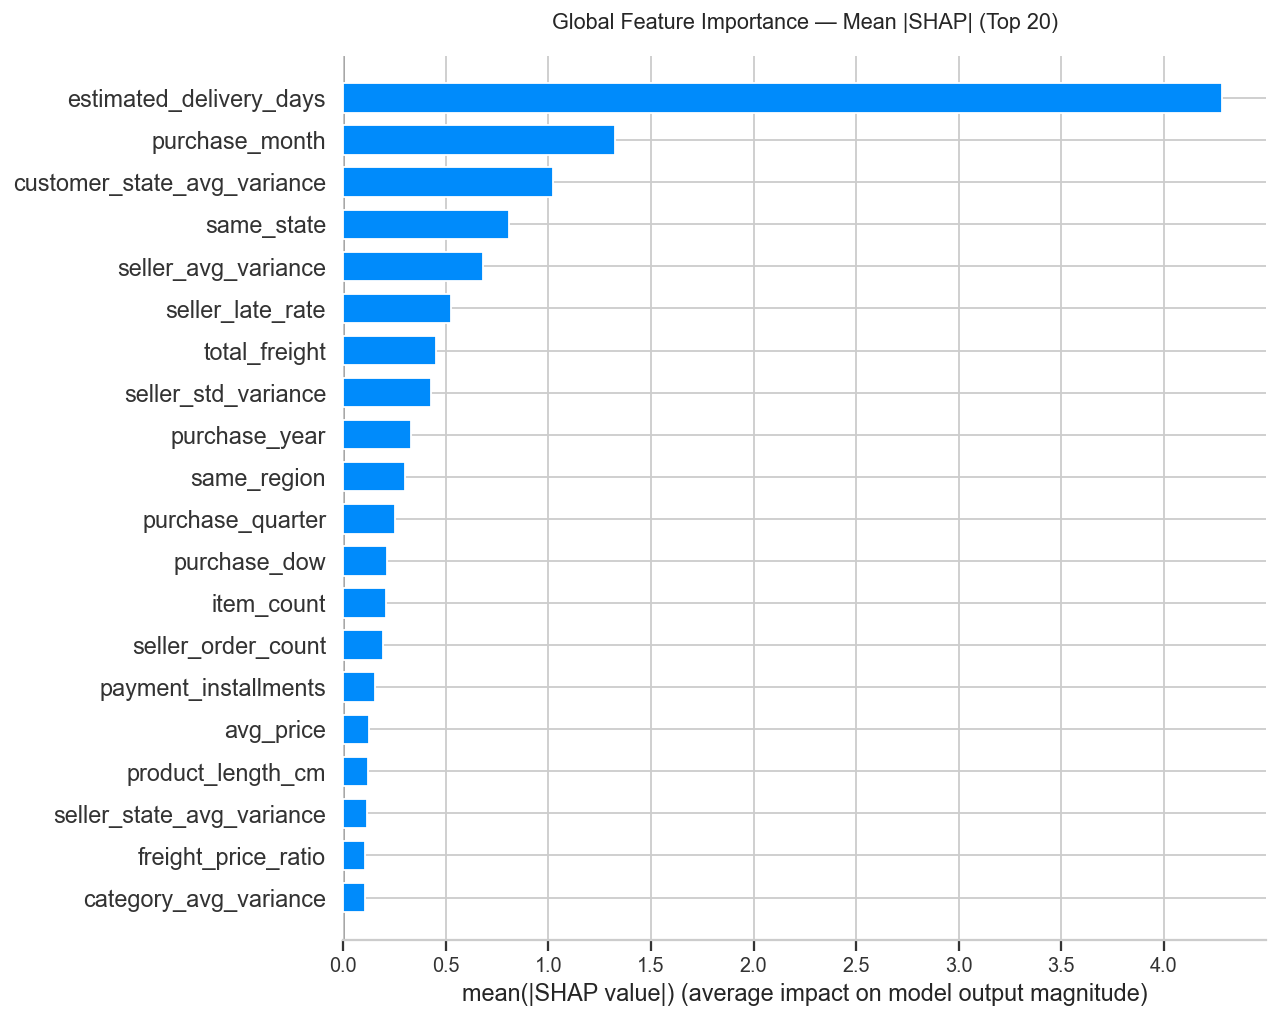

✓ SHAP bar plot saved


In [6]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURES,
    plot_type="bar",
    max_display=20,
    show=False,
    plot_size=(10, 8)
)
plt.title("Global Feature Importance — Mean |SHAP| (Top 20)", fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/shap_bar.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ SHAP bar plot saved")

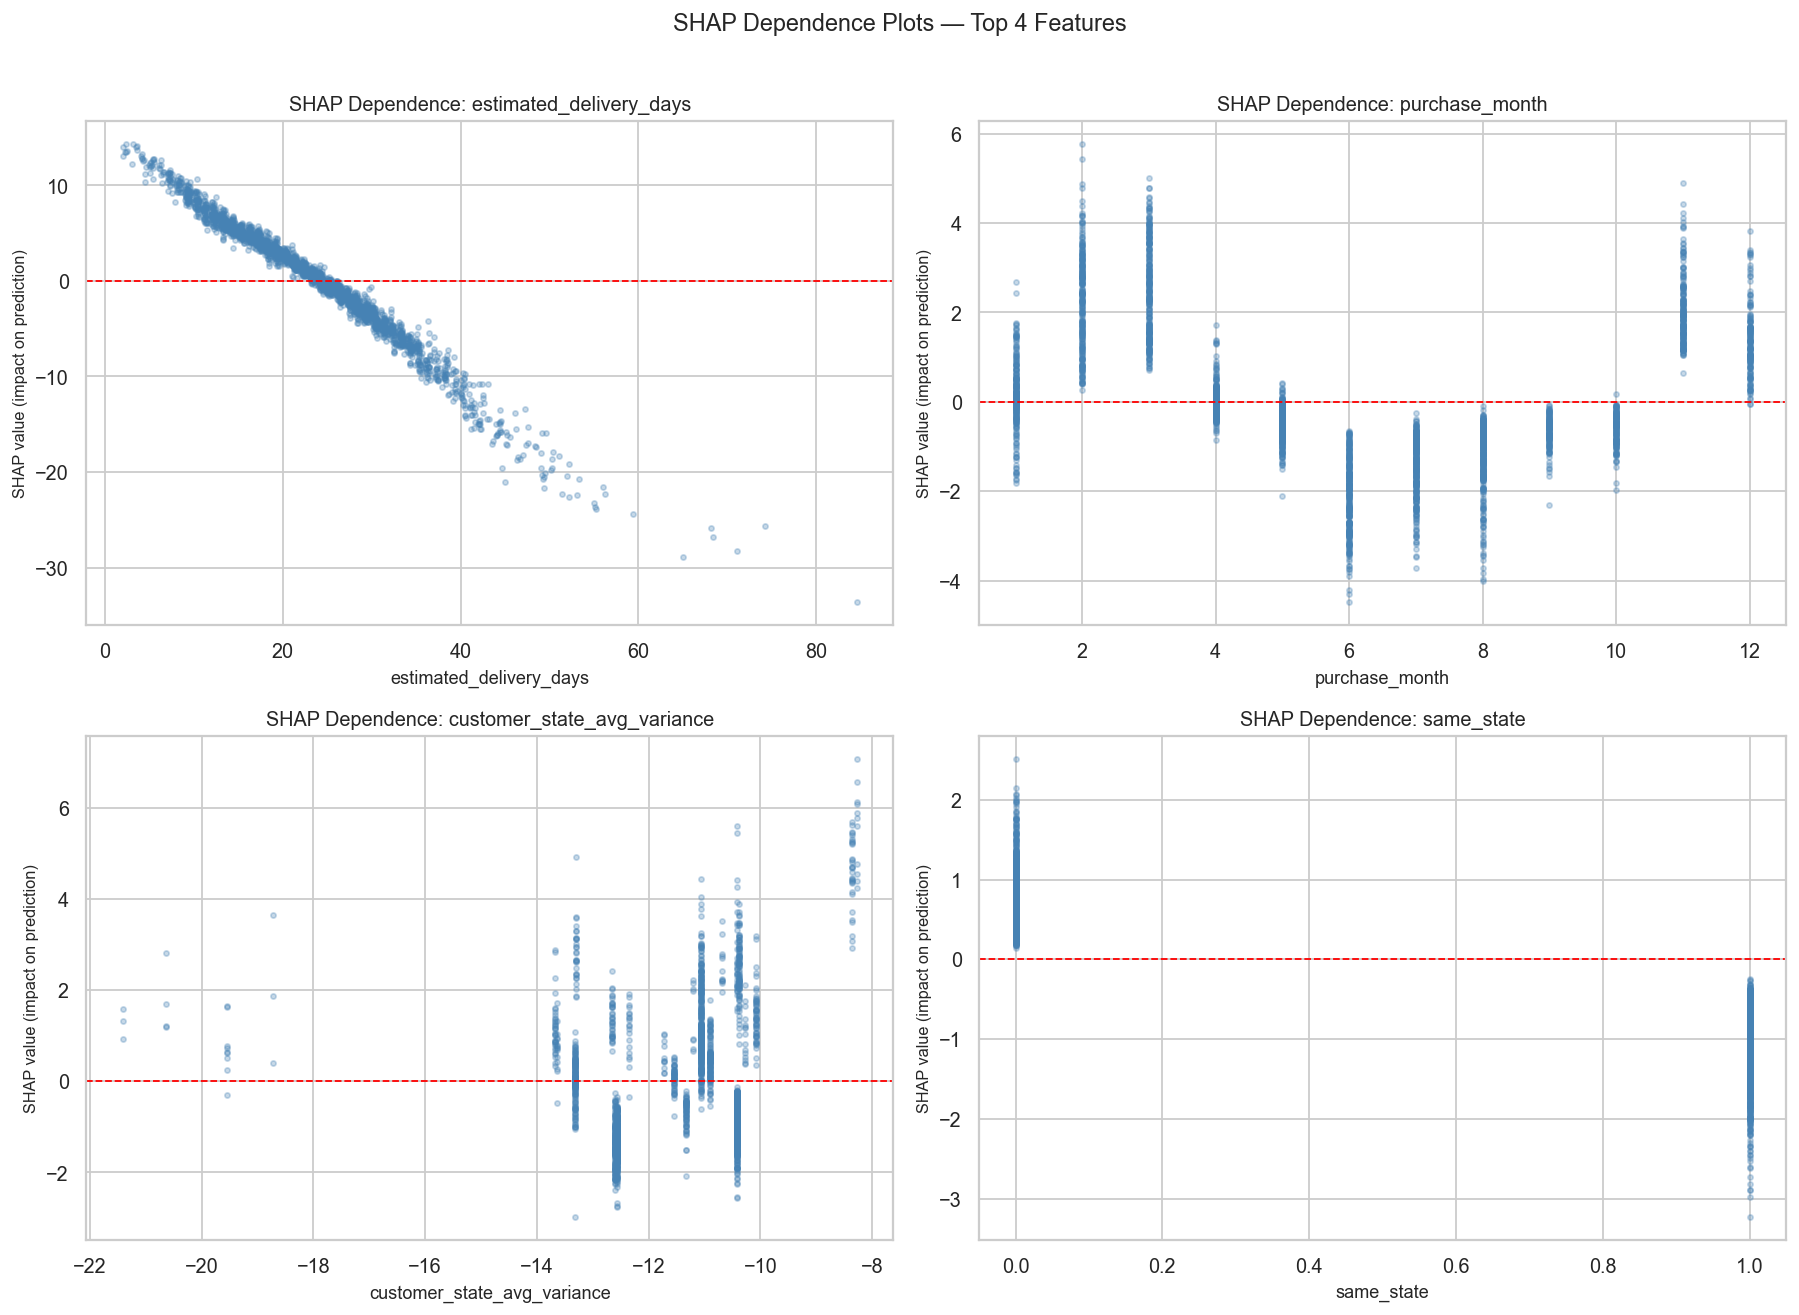

✓ SHAP dependence plots saved


In [7]:
top4 = shap_importance["feature"].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top4):
    feat_idx = FEATURES.index(feat)
    feat_vals  = X_shap[feat].values
    shap_vals  = shap_values[:, feat_idx]

    axes[i].scatter(feat_vals, shap_vals,
                    alpha=0.3, s=8, color="steelblue")
    axes[i].axhline(0, color="red", linestyle="--", linewidth=1)
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel("SHAP value (impact on prediction)", fontsize=9)
    axes[i].set_title(f"SHAP Dependence: {feat}", fontsize=11)

plt.suptitle("SHAP Dependence Plots — Top 4 Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/shap_dependence_top4.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ SHAP dependence plots saved")

In [8]:
print("FEATURE INTERPRETATION SUMMARY\n")
print("=" * 65)

interpretations = {
    "estimated_delivery_days": (
        "STRONGEST predictor. Longer estimated windows → model predicts "
        "more negative variance (earlier delivery). Olist sets longer "
        "buffers for complex routes — these systematically arrive earlier "
        "relative to estimate."
    ),
    "seller_avg_variance": (
        "Second strongest. A seller's historical average variance is a "
        "reliable signal of future behavior. Sellers who were consistently "
        "late/early tend to repeat that pattern."
    ),
    "seller_late_rate": (
        "Complements seller_avg_variance. Proportion of a seller's past "
        "orders that were late. High late rate → model pushes prediction "
        "toward positive (late) territory."
    ),
    "purchase_month": (
        "Seasonal signal. Nov-Dec (holiday season) and Q1 2018 show "
        "higher errors — carrier capacity constraints during peak periods "
        "are hard to predict from order-level data alone."
    ),
    "same_state": (
        "Geographic signal. Same-state deliveries arrive earlier relative "
        "to estimate. Cross-state routes have more variance likely due to "
        "inter-state logistics complexity."
    ),
    "customer_state_avg_variance": (
        "States in the North/Northeast (AL, MA, SE, PI) show higher "
        "variance — likely due to last-mile infrastructure limitations "
        "in those regions."
    ),
    "seller_state_avg_variance": (
        "Sellers in AM (Amazonas) show extreme positive variance. "
        "SP sellers dominate volume but show moderate variance."
    ),
    "total_freight": (
        "Higher freight → more complex/heavier shipment → slightly "
        "more variance in delivery time."
    ),
}

for feat, explanation in interpretations.items():
    rank = shap_importance[shap_importance["feature"] == feat].index[0] + 1
    mean_shap = shap_importance[
        shap_importance["feature"] == feat
    ]["mean_abs_shap"].values[0]
    print(f"\n  Rank #{rank} — {feat}")
    print(f"  Mean |SHAP| : {mean_shap:.4f}")
    print(f"  Insight     : {explanation}")
    print()

FEATURE INTERPRETATION SUMMARY


  Rank #1 — estimated_delivery_days
  Mean |SHAP| : 4.2850
  Insight     : STRONGEST predictor. Longer estimated windows → model predicts more negative variance (earlier delivery). Olist sets longer buffers for complex routes — these systematically arrive earlier relative to estimate.


  Rank #5 — seller_avg_variance
  Mean |SHAP| : 0.6794
  Insight     : Second strongest. A seller's historical average variance is a reliable signal of future behavior. Sellers who were consistently late/early tend to repeat that pattern.


  Rank #6 — seller_late_rate
  Mean |SHAP| : 0.5230
  Insight     : Complements seller_avg_variance. Proportion of a seller's past orders that were late. High late rate → model pushes prediction toward positive (late) territory.


  Rank #2 — purchase_month
  Mean |SHAP| : 1.3254
  Insight     : Seasonal signal. Nov-Dec (holiday season) and Q1 2018 show higher errors — carrier capacity constraints during peak periods are hard to predi

In [9]:
# Pick one late order and one early order for local SHAP explanation

late_mask  = y_shap > 5
early_mask = y_shap < -20

late_idx  = np.where(late_mask)[0][0]  if late_mask.any()  else 0
early_idx = np.where(early_mask)[0][0] if early_mask.any() else 1

print("LOCAL EXPLANATIONS — Single Order Deep Dive\n")

for label, idx in [("LATE ORDER", late_idx), ("EARLY ORDER", early_idx)]:
    print(f"  {'='*55}")
    print(f"  {label}")
    print(f"  {'='*55}")
    print(f"  Actual variance    : {y_shap.iloc[idx]:.3f} days")
    print(f"  Predicted variance : {model.predict(X_shap.iloc[[idx]])[0]:.3f} days")
    print(f"  Base value         : {explainer.expected_value:.3f} days")
    print(f"\n  Top contributing features (SHAP):")

    order_shap = shap_values[idx]
    contrib = pd.Series(order_shap, index=FEATURES).sort_values(key=abs, ascending=False)

    print(f"  {'Feature':<40} {'SHAP Value':>12} {'Feature Value':>15}")
    print(f"  {'-'*70}")
    for feat, sv in contrib.head(10).items():
        fv = X_shap.iloc[idx][feat]
        direction = "▲ pushes late" if sv > 0 else "▼ pushes early"
        print(f"  {feat:<40} {sv:>+12.4f}  {fv:>12.3f}   {direction}")
    print()

LOCAL EXPLANATIONS — Single Order Deep Dive

  LATE ORDER
  Actual variance    : 9.859 days
  Predicted variance : 3.852 days
  Base value         : -11.236 days

  Top contributing features (SHAP):
  Feature                                    SHAP Value   Feature Value
  ----------------------------------------------------------------------
  purchase_month                                +3.2777         3.000   ▲ pushes late
  customer_state_avg_variance                   +2.9189       -10.373   ▲ pushes late
  seller_avg_variance                           +2.3522        -7.032   ▲ pushes late
  freight_price_ratio                           +1.5980         1.547   ▲ pushes late
  seller_late_rate                              +1.3846         0.146   ▲ pushes late
  same_state                                    +0.8646         0.000   ▲ pushes late
  purchase_quarter                              +0.8512         1.000   ▲ pushes late
  estimated_delivery_days                       +0.850

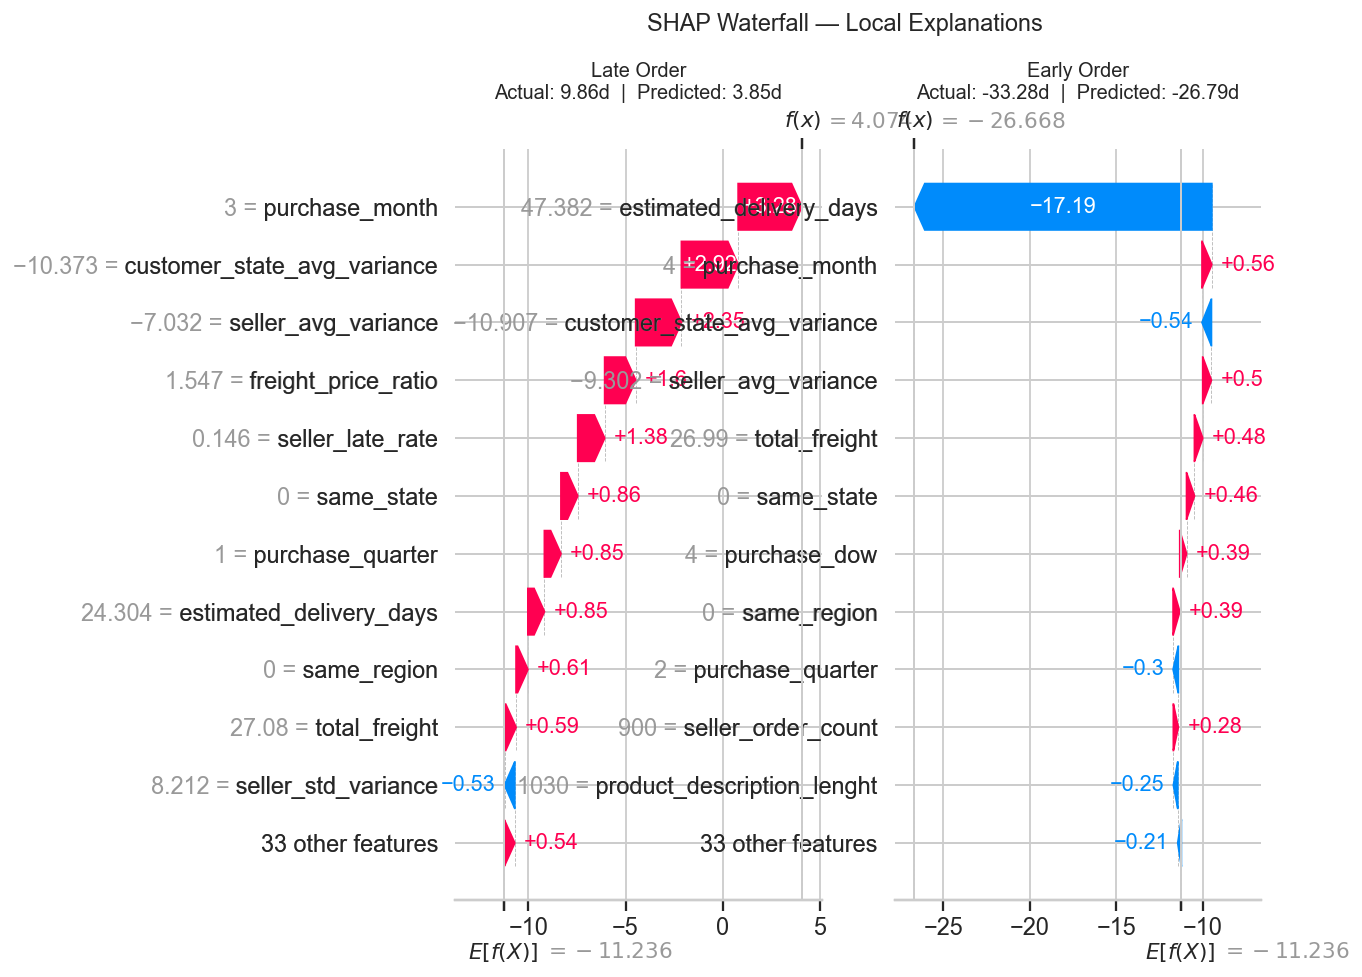

✓ Waterfall plots saved


In [10]:
shap_explanation = shap.Explanation(
    values        = shap_values,
    base_values   = np.full(len(X_shap), explainer.expected_value),
    data          = X_shap.values,
    feature_names = FEATURES
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (label, idx) in zip(axes, [("Late Order", late_idx), ("Early Order", early_idx)]):
    plt.sca(ax)
    shap.waterfall_plot(shap_explanation[idx], max_display=12, show=False)
    ax.set_title(
        f"{label}\nActual: {y_shap.iloc[idx]:.2f}d  |  "
        f"Predicted: {model.predict(X_shap.iloc[[idx]])[0]:.2f}d",
        fontsize=11
    )

plt.suptitle("SHAP Waterfall — Local Explanations", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/shap_waterfall.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Waterfall plots saved")

In [11]:
print("SHAP VALUE SIGN SANITY CHECK\n")
print("  Positive SHAP = pushes prediction toward LATE (higher variance)")
print("  Negative SHAP = pushes prediction toward EARLY (lower variance)\n")

print(f"  {'Feature':<40} {'Mean SHAP':>12} {'Direction':>15}")
print("  " + "-" * 70)

mean_shap_signed = pd.Series(
    shap_values.mean(axis=0), index=FEATURES
).sort_values()

for feat, val in mean_shap_signed.items():
    direction = "pushes LATE  ▲" if val > 0 else "pushes EARLY ▼"
    print(f"  {feat:<40} {val:>+12.4f}  {direction}")

SHAP VALUE SIGN SANITY CHECK

  Positive SHAP = pushes prediction toward LATE (higher variance)
  Negative SHAP = pushes prediction toward EARLY (lower variance)

  Feature                                     Mean SHAP       Direction
  ----------------------------------------------------------------------
  purchase_year                                 -0.1616  pushes EARLY ▼
  total_freight                                 -0.0561  pushes EARLY ▼
  customer_state_avg_variance                   -0.0506  pushes EARLY ▼
  same_region                                   -0.0407  pushes EARLY ▼
  price_per_item                                -0.0254  pushes EARLY ▼
  product_weight_g                              -0.0166  pushes EARLY ▼
  product_width_cm                              -0.0101  pushes EARLY ▼
  product_length_cm                             -0.0100  pushes EARLY ▼
  purchase_black_friday                         -0.0073  pushes EARLY ▼
  product_height_cm                         

In [12]:
shap_importance_dict = shap_importance.set_index("feature")["mean_abs_shap"].to_dict()

interpretation_output = {
    "method"              : "SHAP TreeExplainer",
    "sample_size"         : SHAP_SAMPLE_SIZE,
    "base_value"          : float(explainer.expected_value),
    "feature_importance"  : {
        k: round(float(v), 6)
        for k, v in shap_importance_dict.items()
    },
    "top_5_features"      : shap_importance["feature"].head(5).tolist(),
}

with open("../models/shap_importance.json", "w") as f:
    json.dump(interpretation_output, f, indent=2)

print("✓ SHAP importance saved to models/shap_importance.json")
print(f"\n  PHASE 11 SUMMARY")
print(f"  {'─'*50}")
print(f"  Method         : SHAP TreeExplainer")
print(f"  Sample size    : {SHAP_SAMPLE_SIZE} test orders")
print(f"  Base value     : {explainer.expected_value:.4f} days")
print(f"\n  Top 5 features by mean |SHAP|:")
for i, row in shap_importance.head(5).iterrows():
    print(f"    {i+1}. {row['feature']:<40} {row['mean_abs_shap']:.4f}")
print(f"\n  Plots saved:")
for fname in ["shap_summary.png", "shap_bar.png",
              "shap_dependence_top4.png", "shap_waterfall.png"]:
    print(f"    ../data/processed/{fname}")

✓ SHAP importance saved to models/shap_importance.json

  PHASE 11 SUMMARY
  ──────────────────────────────────────────────────
  Method         : SHAP TreeExplainer
  Sample size    : 3000 test orders
  Base value     : -11.2357 days

  Top 5 features by mean |SHAP|:
    1. estimated_delivery_days                  4.2850
    2. purchase_month                           1.3254
    3. customer_state_avg_variance              1.0204
    4. same_state                               0.8084
    5. seller_avg_variance                      0.6794

  Plots saved:
    ../data/processed/shap_summary.png
    ../data/processed/shap_bar.png
    ../data/processed/shap_dependence_top4.png
    ../data/processed/shap_waterfall.png
